# Librerias

In [ ]:
!pip install -q segmentation-models-pytorch==0.3.3


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.2 MB/s eta 0:00:00


In [ ]:
!pip install -q lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 64.2 MB/s eta 0:00:00


# Librerias

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import random

import pandas as pd
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
from torchmetrics import JaccardIndex
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
import torchvision.transforms as T
import torchvision.transforms.functional as F
from torchvision.transforms import InterpolationMode

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from lightning import Trainer
import torchmetrics


# Carga de la base de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Colab/Geotermia/DeepGlobe"
TRAIN_IMG_DIR = f"{BASE_DIR}/training_data/images"
TRAIN_MASK_DIR = f"{BASE_DIR}/training_data/masks"
TEST_IMG_DIR  = f"{BASE_DIR}/test_data/images"
TEST_MASK_DIR = f"{BASE_DIR}/test_data/masks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Preprocesamiento y transformación de datos

In [ ]:

class SatelliteSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

        # Lista de imágenes
        self.image_paths = sorted([
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]


        mask_filename = img_path.name.replace("_sat.jpg", "_mask.png")
        mask_path = self.mask_dir / mask_filename

        # Cargar imagen RGB y máscara
        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        return {"image": image, "mask": mask}

# Emparejamiento/ Concatenación imágenes y máscaras

In [ ]:
ds = SatelliteSegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)

print("Número de pares:", len(ds))

sample = ds[0]
print("Imagen:", sample["image"].size)
print("Mascara:", sample["mask"].size)

Número de pares: 683
Imagen: (2448, 2448)
Mascara: (2448, 2448)


In [ ]:

#  MAPA DE COLORES (DeepGlobe)

COLOR_MAP = {
    (0,   255, 255): 0,  # Urban (cyan)
    (255, 255,   0): 1,  # Agriculture (yellow)
    (255,   0, 255): 2,  # Rangeland (magenta)
    (0,   255,   0): 3,  # Forest (green)
    (0,     0, 255): 4,  # Water (blue)
    (255, 255, 255): 5,  # Barren (white)
    (0,     0,   0): 6,  # Unknown (black)
}


# Convertir RGB

def rgb_to_class(mask_rgb):
    mask_rgb = np.array(mask_rgb)
    h, w, _ = mask_rgb.shape
    mask_class = np.zeros((h, w), dtype=np.int64)

    for color, cls in COLOR_MAP.items():
        r, g, b = color
        matches = (mask_rgb == [r, g, b]).all(axis=2)
        mask_class[matches] = cls

    return mask_class


class SimpleSegmentationTransform:
    def __init__(self, size=(256, 256)):
        self.size = size
        self.img_transform = T.Compose([
            T.Resize(size, interpolation=InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
        self.mask_resize = T.Resize(size, interpolation=InterpolationMode.NEAREST)

    def __call__(self, image, mask):
        image = self.img_transform(image)
        mask = self.mask_resize(mask)
        mask = rgb_to_class(mask)
        mask = torch.from_numpy(mask).long()
        return image, mask


#  Transformación para Train-Aumentación

class TrainSegmentationTransform:
    def __init__(self, size=(256, 256)):
        self.size = size
        self.img_resize = T.Resize(size, interpolation=InterpolationMode.BILINEAR)
        self.mask_resize = T.Resize(size, interpolation=InterpolationMode.NEAREST)
        self.to_tensor = T.ToTensor()
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

    def __call__(self, image, mask):

# Aumentación

        # Flip horizontal
        if random.random() < 0.5:
            image = F.hflip(image)
            mask = F.hflip(mask)

        # Flip vertical
        if random.random() < 0.5:
            image = F.vflip(image)
            mask = F.vflip(mask)

        # Rotación pequeña
        angle = random.uniform(-10, 10)
        image = F.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
        mask  = F.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        # Resize + normalize
        image = self.img_resize(image)
        image = self.to_tensor(image)
        image = self.normalize(image)

        mask = self.mask_resize(mask)
        mask = rgb_to_class(mask)
        mask = torch.from_numpy(mask).long()

        return image, mask

In [ ]:

NUM_CLASSES = 7

class AttentionUNetModule(L.LightningModule):
    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        lr: float = 1e-4,
        encoder_name: str = "resnet34",
        encoder_weights: str = "imagenet",
    ):
        super().__init__()
        self.save_hyperparameters()


        # Modelo Attention U-Net

        self.model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes,
            decoder_attention_type="scse",
        )

        # Pérdida: CrossEntropy
        self.loss_fn = nn.CrossEntropyLoss()

        # Métricas IoU (mIoU)
        self.train_iou = torchmetrics.JaccardIndex(
            task="multiclass", num_classes=num_classes
        )
        self.val_iou = torchmetrics.JaccardIndex(
            task="multiclass", num_classes=num_classes
        )

    def forward(self, x):
        # smp.Unet devuelve logits (B, C, H, W)
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch["image"], batch["mask"]
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = logits.argmax(dim=1)
        self.train_iou(preds, y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_mIoU", self.train_iou, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch["image"], batch["mask"]
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = logits.argmax(dim=1)
        self.val_iou(preds, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_mIoU", self.val_iou, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        return optimizer

# Dataloader y entrenamiento Attention U-Net

In [ ]:

# Define a LightningDataModule
class DeepGlobeDataModule(L.LightningDataModule):
    def __init__(self, train_img_dir, train_mask_dir, test_img_dir, test_mask_dir, batch_size=4, num_workers=2, image_size=(256, 256)):
        super().__init__()
        self.train_img_dir = train_img_dir
        self.train_mask_dir = train_mask_dir
        self.test_img_dir = test_img_dir
        self.test_mask_dir = test_mask_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.image_size = image_size

        self.train_transform = TrainSegmentationTransform(size=self.image_size)
        self.val_test_transform = SimpleSegmentationTransform(size=self.image_size)

    def setup(self, stage=None):
        # Split training data into train and validation sets
        full_dataset = SatelliteSegmentationDataset(self.train_img_dir, self.train_mask_dir)
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

        train_dataset.dataset.transform = self.train_transform
        val_dataset.dataset.transform = self.val_test_transform

        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = SatelliteSegmentationDataset(self.test_img_dir, self.test_mask_dir, transform=self.val_test_transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, num_workers=self.num_workers)


datamodule = DeepGlobeDataModule(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR, TEST_IMG_DIR, TEST_MASK_DIR,
    batch_size=4, num_workers=2, image_size=(256, 256)
)

# Crear el modelo Attention U-Net
model_attunet = AttentionUNetModule(
    num_classes=NUM_CLASSES,
    lr=1e-4,
    encoder_name="resnet34",
    encoder_weights="imagenet"
)

# Logger CSV
csv_logger = CSVLogger(save_dir="lightning_logs", name="attunet_metrics")

#  EarlyStopping
early_stop = EarlyStopping(
    monitor="val_mIoU",
    mode="max",
    patience=5,
    verbose=True,
)

# Checkpoint
checkpoint = ModelCheckpoint(
    dirpath="checkpoints_attunet/",
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    filename="attunet-{epoch:02d}-{val_mIoU:.3f}",
    verbose=True,
)

# Trainer
trainer = Trainer(
    max_epochs=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[early_stop, checkpoint],
    logger=csv_logger,
)

#  Entrenar
trainer.fit(model_attunet, datamodule=datamodule)

print("Mejor modelo guardado en:", checkpoint.best_model_path)


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 362MB/s]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | model     | Unet                   | 24.6 M | train
1 | loss_fn   | CrossEntropyLoss       | 0      | train
2 | train_iou | MulticlassJaccardIndex | 0      | train
3 | val_iou   | MulticlassJaccardIndex | 0      | train
-------------------------------------------------------------
24.6 M    Trainable params
0         Non-trainable params
24.6 M    Total params
98.205    Total estimated model params size (MB)
281       Modules 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 18, global step 2603: 'val_mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 18, global step 2603: 'val_mIoU' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Metric val_mIoU improved by 0.004 >= min_delta = 0.0. New best score: 0.554
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_mIoU improved by 0.004 >= min_delta = 0.0. New best score: 0.554
INFO: Epoch 19, global step 2740: 'val_mIoU' reached 0.55415 (best 0.55415), saving model to '/content/checkpoints_attunet/attunet-epoch=19-val_mIoU=0.554.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 19, global step 2740: 'val_mIoU' reached 0.55415 (best 0.55415), saving model to '/content/checkpoints_attunet/attunet-epoch=19-val_mIoU=0.554.ckpt' as top 1
INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Mejor modelo guardado en: /content/checkpoints_attunet/attunet-epoch=19-val_mIoU=0.554.ckpt


# Curva función de pérdida y métrica IoU entrenamiento y validación

Leyendo métricas de: lightning_logs/attunet_metrics/version_0/metrics.csv
Columnas disponibles:
 Index(['epoch', 'step', 'train_loss', 'train_mIoU', 'val_loss', 'val_mIoU'], dtype='object')


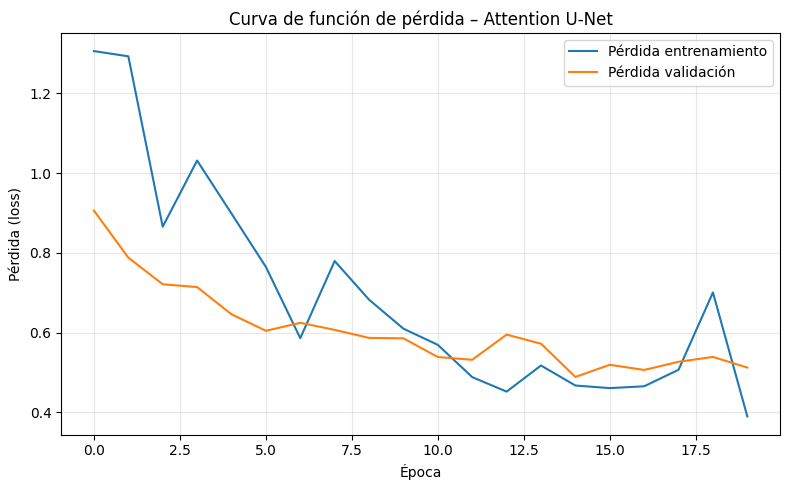

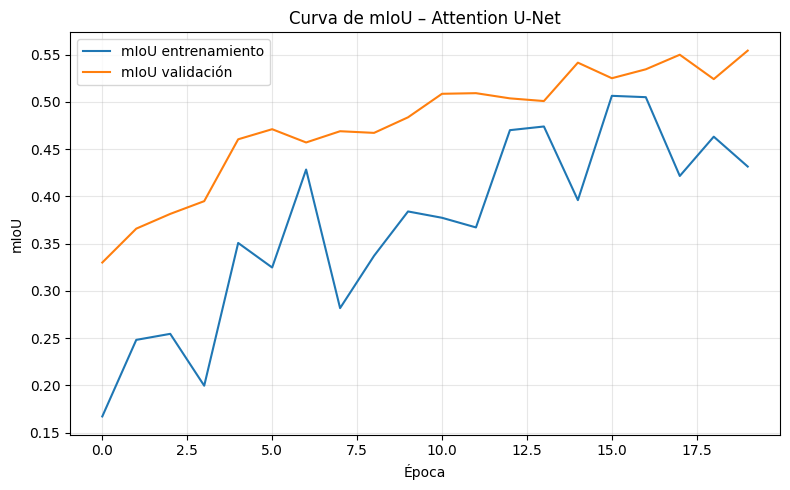

Gráficas guardadas como:
  - attunet_loss_curve.png
  - attunet_miou_curve.png


In [ ]:

metrics_path = "lightning_logs/attunet_metrics/version_0/metrics.csv"

if not os.path.exists(metrics_path):
    print("No se encontró metrics.csv en:", metrics_path)
else:
    print("Leyendo métricas de:", metrics_path)
    df = pd.read_csv(metrics_path)
    print("Columnas disponibles:\n", df.columns)

    df_train = df[df["train_loss"].notna()].copy()
    df_val   = df[df["val_loss"].notna()].copy()


    train_epoch = (
        df_train.groupby("epoch")[["train_loss", "train_mIoU"]]
        .mean()
        .reset_index()
    )
    val_epoch = (
        df_val.groupby("epoch")[["val_loss", "val_mIoU"]]
        .mean()
        .reset_index()
    )


    # 1) Curva de pérdida

    plt.figure(figsize=(8,5))
    plt.plot(train_epoch["epoch"], train_epoch["train_loss"], label="Pérdida entrenamiento")
    plt.plot(val_epoch["epoch"],   val_epoch["val_loss"],   label="Pérdida validación")
    plt.xlabel("Época")
    plt.ylabel("Pérdida (loss)")
    plt.title("Curva de función de pérdida – Attention U-Net")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("attunet_loss_curve.png", dpi=300)
    plt.show()


    # 2) Curva de mIoU

    plt.figure(figsize=(8,5))
    plt.plot(train_epoch["epoch"], train_epoch["train_mIoU"], label="mIoU entrenamiento")
    plt.plot(val_epoch["epoch"],   val_epoch["val_mIoU"],   label="mIoU validación")
    plt.xlabel("Época")
    plt.ylabel("mIoU")
    plt.title("Curva de mIoU – Attention U-Net")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("attunet_miou_curve.png", dpi=300)
    plt.show()

    print("Gráficas guardadas como:")
    print("  - attunet_loss_curve.png")
    print("  - attunet_miou_curve.png")


# Visualización imágen original+ Ground Truth+ máscara predicha conjunto Train

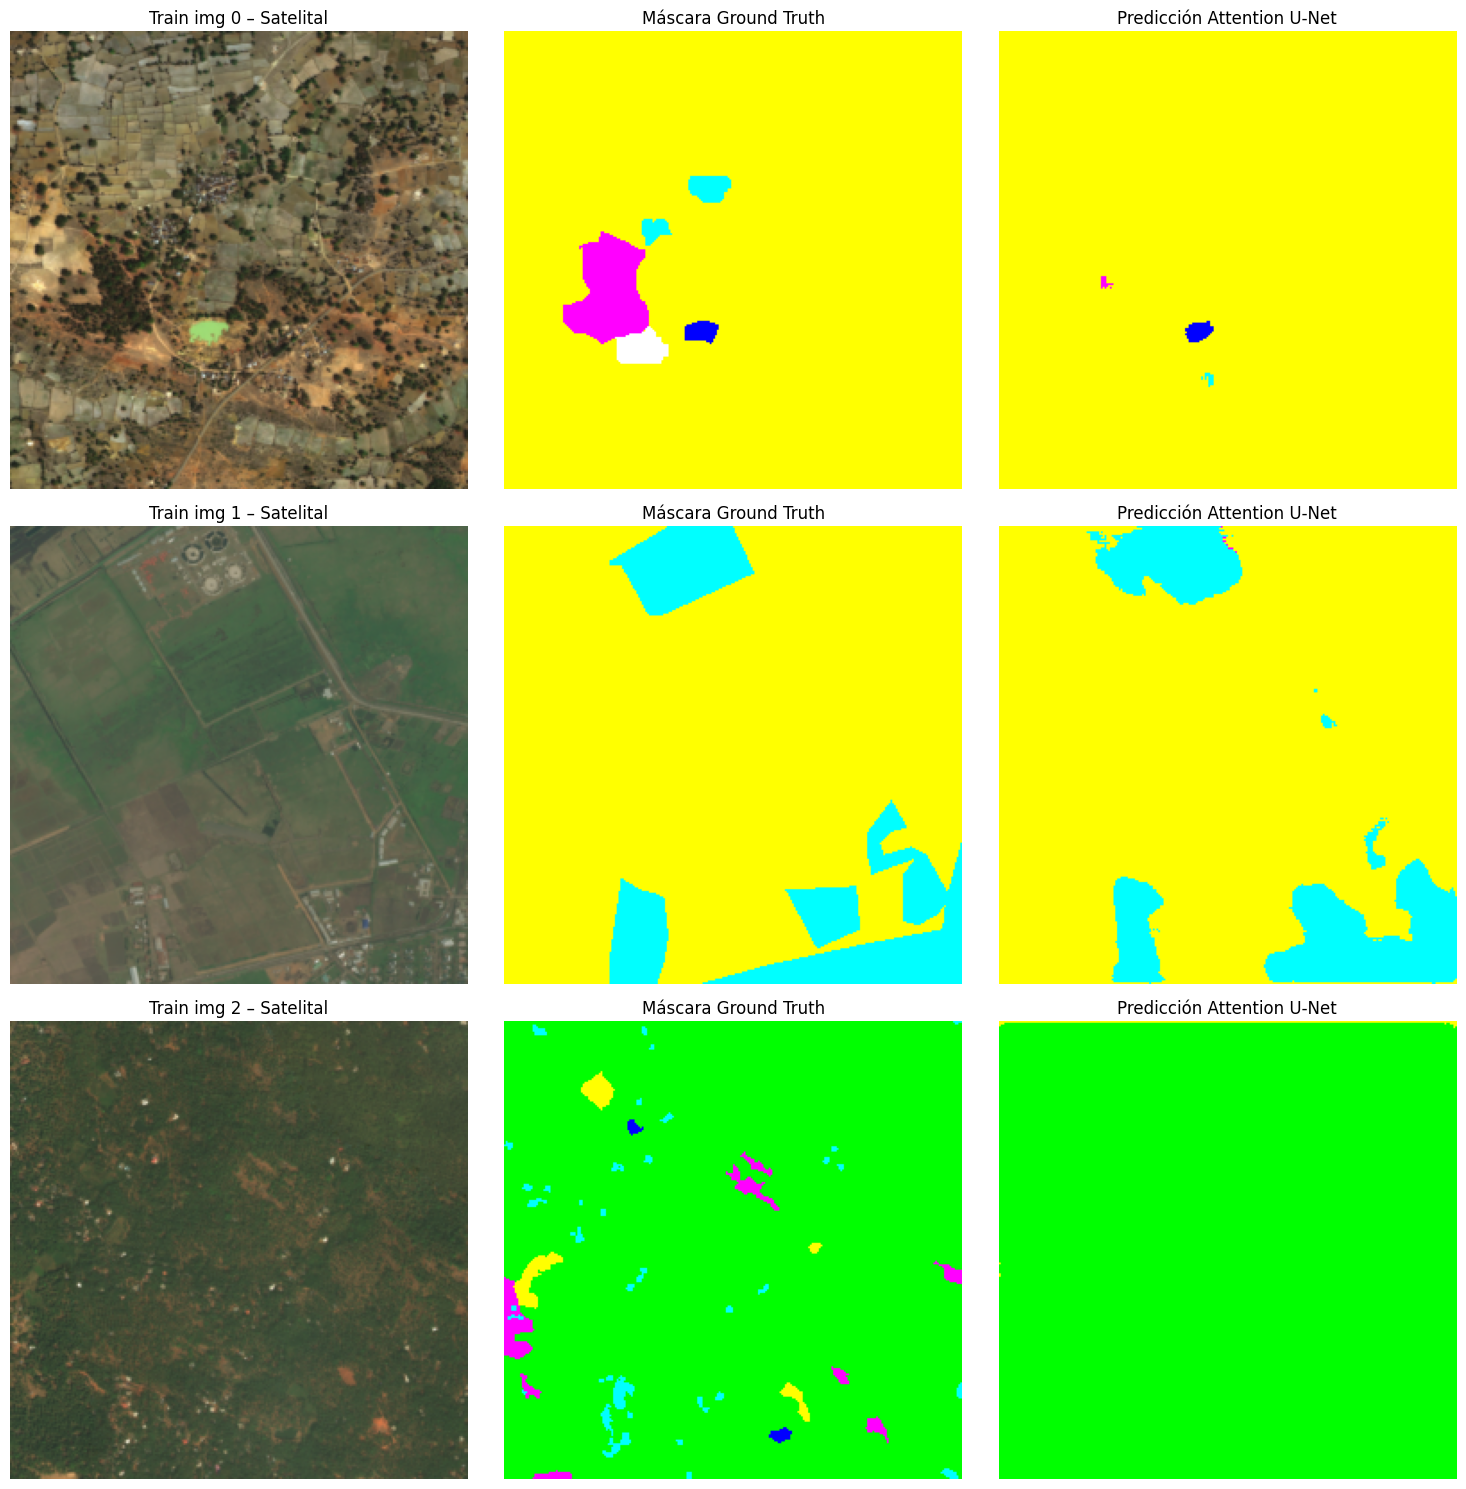

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

best_attunet = AttentionUNetModule.load_from_checkpoint(checkpoint.best_model_path)

best_attunet.to(device)
best_attunet.eval()


INDEX2COLOR = {cls: color for color, cls in COLOR_MAP.items()}

def classes_to_rgb(mask_class):
    mask_class = mask_class.cpu().numpy()
    h, w = mask_class.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in INDEX2COLOR.items():
        rgb[mask_class == cls] = color
    return rgb

# Loader de entrenamiento
train_loader = datamodule.train_dataloader()


batch_train = next(iter(train_loader))
images = batch_train["image"]   # (B,3,H,W)
masks  = batch_train["mask"]    # (B,H,W)

with torch.no_grad():
    logits = best_attunet(images.to(device))
    if isinstance(logits, dict):
        logits = logits["out"]
    preds = logits.argmax(dim=1).cpu()


mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

n_show = min(3, images.size(0))

plt.figure(figsize=(15, 5 * n_show))
for i in range(n_show):
    img = images[i].cpu()
    gt  = masks[i]
    pr  = preds[i]

    img_vis = (img * std + mean).clamp(0,1).permute(1,2,0).numpy()
    gt_rgb  = classes_to_rgb(gt)
    pr_rgb  = classes_to_rgb(pr)

    row = i * 3 + 1

    plt.subplot(n_show, 3, row)
    plt.title(f"Train img {i} – Satelital")
    plt.imshow(img_vis)
    plt.axis("off")

    plt.subplot(n_show, 3, row + 1)
    plt.title("Máscara Ground Truth")
    plt.imshow(gt_rgb)
    plt.axis("off")

    plt.subplot(n_show, 3, row + 2)
    plt.title("Predicción Attention U-Net")
    plt.imshow(pr_rgb)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Métrica global y por clase mIoU del conjunto  Test

In [ ]:
test_loader = datamodule.test_dataloader()

model_eval = best_attunet.to(device)
model_eval.eval()

miou_global = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)
miou_per_class = JaccardIndex(
    task="multiclass", num_classes=NUM_CLASSES, average=None
).to(device)

with torch.no_grad():
    for batch in test_loader:
        x = batch["image"].to(device)
        y = batch["mask"].to(device)

        logits = model_eval(x)
        if isinstance(logits, dict):
            logits = logits["out"]
        preds = logits.argmax(dim=1)

        miou_global.update(preds, y)
        miou_per_class.update(preds, y)

test_miou = miou_global.compute().item()
miou_classes = miou_per_class.compute().cpu().numpy()

print(f"\n=== mIoU GLOBAL en test (Attention U-Net): {test_miou:.3f} ===\n")

clases = ["Urban", "Agriculture", "Rangeland", "Forest", "Water", "Barren", "Unknown"]
for i, m in enumerate(miou_classes):
    print(f"Clase {i} ({clases[i]}): IoU = {m:.3f}")



=== mIoU GLOBAL en test (Attention U-Net): 0.517 ===

Clase 0 (Urban): IoU = 0.628
Clase 1 (Agriculture): IoU = 0.783
Clase 2 (Rangeland): IoU = 0.218
Clase 3 (Forest): IoU = 0.702
Clase 4 (Water): IoU = 0.672
Clase 5 (Barren): IoU = 0.618
Clase 6 (Unknown): IoU = 0.000


# Visualización de imágen original + Ground Truth + Máscara predicha conjunto Test

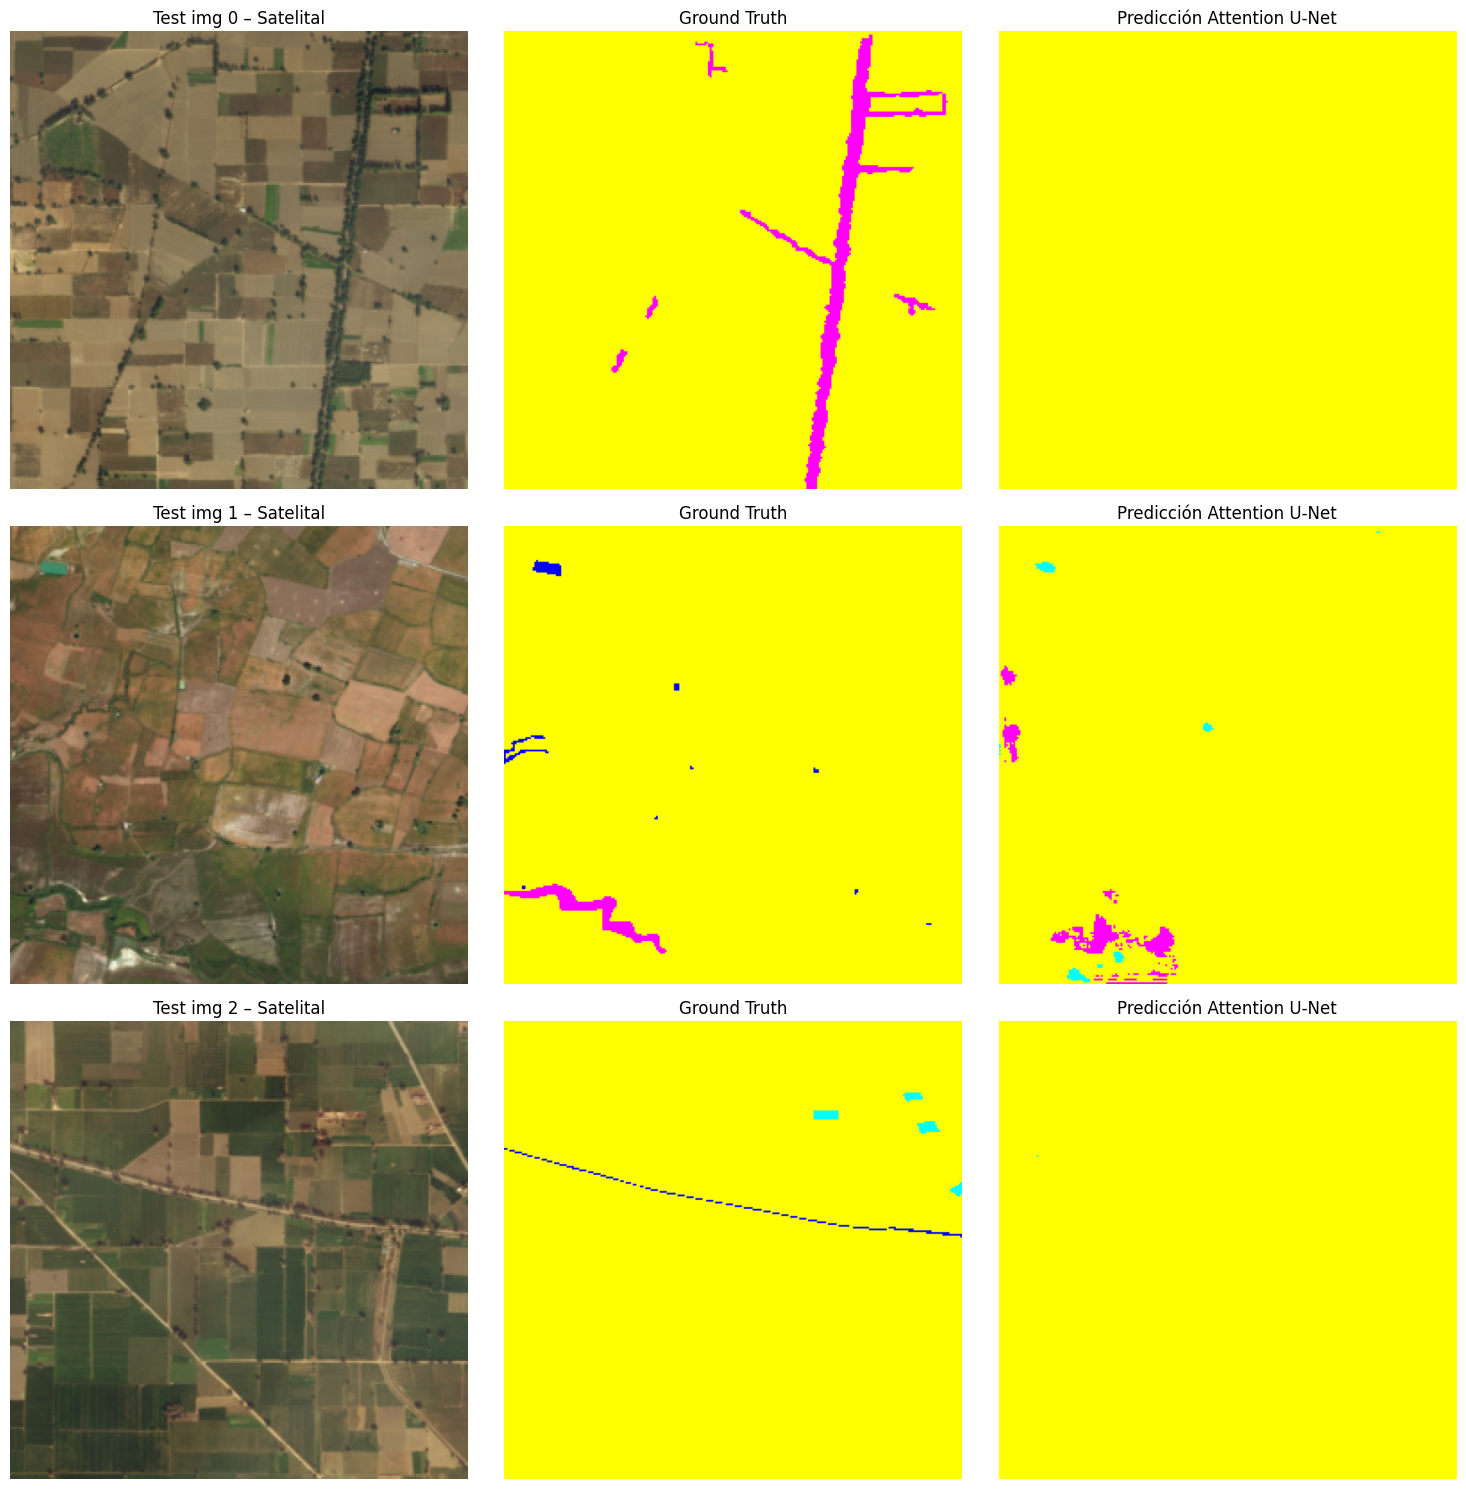

In [ ]:
test_loader = datamodule.test_dataloader()
batch_test = next(iter(test_loader))

images_t = batch_test["image"]
masks_t  = batch_test["mask"]

with torch.no_grad():
    logits_t = best_attunet(images_t.to(device))
    if isinstance(logits_t, dict):
        logits_t = logits_t["out"]
    preds_t = logits_t.argmax(dim=1).cpu()

n_show = min(3, images_t.size(0))

plt.figure(figsize=(15, 5 * n_show))

for i in range(n_show):
    img = images_t[i].cpu()
    gt  = masks_t[i]
    pr  = preds_t[i]

    img_vis = (img * std + mean).clamp(0,1).permute(1,2,0).numpy()
    gt_rgb  = classes_to_rgb(gt)
    pr_rgb  = classes_to_rgb(pr)

    row = i * 3 + 1

    plt.subplot(n_show, 3, row)
    plt.title(f"Test img {i} – Satelital")
    plt.imshow(img_vis)
    plt.axis("off")

    plt.subplot(n_show, 3, row + 1)
    plt.title("Ground Truth")
    plt.imshow(gt_rgb)
    plt.axis("off")

    plt.subplot(n_show, 3, row + 2)
    plt.title("Predicción Attention U-Net")
    plt.imshow(pr_rgb)
    plt.axis("off")

plt.tight_layout()
plt.show()


# Fine Tuning

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Cargar el mejor checkpoint actual de Attention U-Net

best_att_path = "/content/checkpoints_attunet/attunet-epoch=19-val_mIoU=0.554.ckpt"
print("Cargando modelo base desde:", best_att_path)

attunet_ft = AttentionUNetModule.load_from_checkpoint(
    best_att_path,
    num_classes=NUM_CLASSES,
    lr=1e-5,
    encoder_name="resnet34",
    encoder_weights=None,
)
attunet_ft.to(device)


csv_logger_ft = CSVLogger("lightning_logs", name="attunet_finetune")


# Callbacks: EarlyStopping

early_stop_ft = EarlyStopping(
    monitor="val_mIoU",
    mode="max",
    patience=4,
    verbose=True,
)

checkpoint_ft = ModelCheckpoint(
    dirpath="checkpoints_attunet_finetune/",
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    filename="attunet-ft-epoch={epoch:02d}-val_mIoU={val_mIoU:.3f}",
    verbose=True,
)


trainer_ft = Trainer(
    max_epochs=15,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[early_stop_ft, checkpoint_ft],
    logger=csv_logger_ft,
)



trainer_ft.fit(attunet_ft, datamodule=datamodule)


# Cargar el mejor modelo del fine-tuning

best_ft_path = checkpoint_ft.best_model_path
print("Mejor modelo de fine-tuning:", best_ft_path)

best_attunet_ft = AttentionUNetModule.load_from_checkpoint(
    best_ft_path,
    num_classes=NUM_CLASSES,
    lr=1e-5,
    encoder_name="resnet34",
    encoder_weights=None,
)

print("Modelo de fine-tuning cargado.")


Cargando modelo base desde: /content/checkpoints_attunet/attunet-epoch=19-val_mIoU=0.554.ckpt


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | model     | Unet                   | 24.6 M | train
1 | loss_fn   | CrossEntropyLoss       | 0      | train
2 | train_iou | MulticlassJaccardIndex | 0      | train
3 | val_iou   | MulticlassJaccardIndex | 0      | train
-------------------------------------------------------------
24.6 M    Trainable params
0         Non-trainable params
24.6 M    Total params
98.205    Total estimated model params size (MB)
281       Modules in train mode
0         Modules in eval mode
INFO:li

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Metric val_mIoU improved by 0.004 >= min_delta = 0.0. New best score: 0.651
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_mIoU improved by 0.004 >= min_delta = 0.0. New best score: 0.651
INFO: Epoch 13, global step 1918: 'val_mIoU' reached 0.65101 (best 0.65101), saving model to '/content/checkpoints_attunet_finetune/attunet-ft-epoch=epoch=13-val_mIoU=val_mIoU=0.651.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 13, global step 1918: 'val_mIoU' reached 0.65101 (best 0.65101), saving model to '/content/checkpoints_attunet_finetune/attunet-ft-epoch=epoch=13-val_mIoU=val_mIoU=0.651.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 14, global step 2055: 'val_mIoU' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 14, global step 2055: 'val_mIoU' was not in top 1
INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


Mejor modelo de fine-tuning: /content/checkpoints_attunet_finetune/attunet-ft-epoch=epoch=13-val_mIoU=val_mIoU=0.651.ckpt
Modelo de fine-tuning cargado.


# Métricas Globales y por clase con Fine Tuning conjunto de Test

In [ ]:

test_loader = datamodule.test_dataloader()

model_eval = best_attunet_ft.to(device)
model_eval.eval()

miou_global = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)
miou_per_class = JaccardIndex(
    task="multiclass", num_classes=NUM_CLASSES, average=None
).to(device)

with torch.no_grad():
    for batch in test_loader:
        x = batch["image"].to(device)
        y = batch["mask"].to(device)

        logits = model_eval(x)
        if isinstance(logits, dict):
            logits = logits["out"]
        preds = logits.argmax(dim=1)

        miou_global.update(preds, y)
        miou_per_class.update(preds, y)

test_miou = miou_global.compute().item()
miou_classes = miou_per_class.compute().cpu().numpy()

print(f"\n=== mIoU GLOBAL en test (Attention U-Net): {test_miou:.3f} ===\n")

clases = ["Urban", "Agriculture", "Rangeland", "Forest", "Water", "Barren", "Unknown"]
for i, m in enumerate(miou_classes):
    print(f"Clase {i} ({clases[i]}): IoU = {m:.3f}")


=== mIoU GLOBAL en test (Attention U-Net): 0.545 ===

Clase 0 (Urban): IoU = 0.673
Clase 1 (Agriculture): IoU = 0.811
Clase 2 (Rangeland): IoU = 0.233
Clase 3 (Forest): IoU = 0.761
Clase 4 (Water): IoU = 0.684
Clase 5 (Barren): IoU = 0.653
Clase 6 (Unknown): IoU = 0.000


# Visualización imágen original + Ground Truth + Máscara predicha

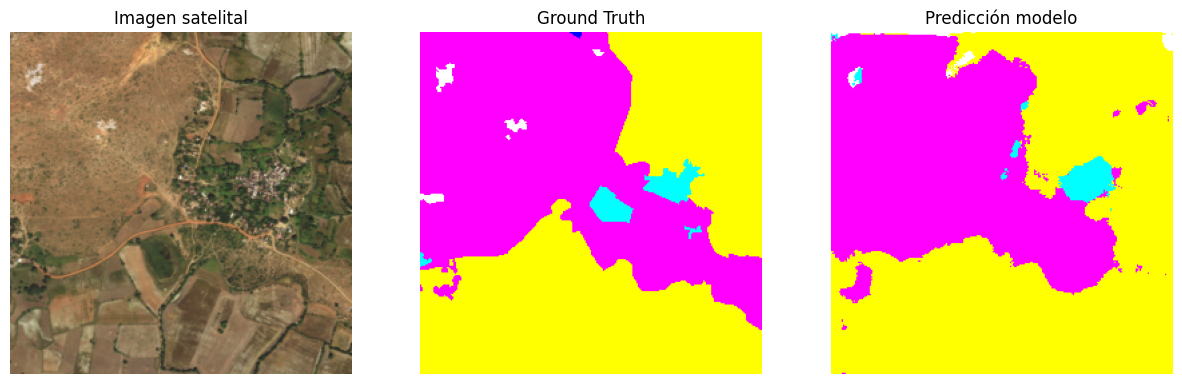

In [ ]:
idx = 35

dataset_test = datamodule.test_dataset

sample_test_item = dataset_test[idx]
image = sample_test_item["image"]
mask = sample_test_item["mask"]


img_tensor = image.unsqueeze(0).to(device)

model = best_attunet_ft.to(device)
model.eval()

with torch.no_grad():
    logits = model(img_tensor)
    if isinstance(logits, dict):
        logits = logits["out"]
    pred = logits.argmax(dim=1).squeeze().cpu()

# Desnormaliza imagen
img_vis = (image.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()

# Convierte máscaras a RGB
gt_rgb  = classes_to_rgb(mask)
pr_rgb  = classes_to_rgb(pred)

# Visualiza
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img_vis); plt.axis("off"); plt.title("Imagen satelital")
plt.subplot(1,3,2); plt.imshow(gt_rgb); plt.axis("off"); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pr_rgb); plt.axis("off"); plt.title("Predicción modelo")
plt.show()
